# **BONUS TASK**
---

In [ ]:
import torch
import torch.nn as nn
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

In [ ]:
# setting up CUDA
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [ ]:
batch_size=100

In [ ]:
# Splitting data into train, test dataset
train_data = FashionMNIST(root='data',train=True ,download=True, transform=transforms.ToTensor())
test_data = FashionMNIST(root='data',train=False ,download=True, transform=transforms.ToTensor())

train_dl = DataLoader(train_data, batch_size)
test_dl = DataLoader(test_data, batch_size)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


#Designing multiple autoencoders with different architectures for experimenting on how Latent space dimensions influences the reconstruction quality

###Autoencoder with latent space dimension of 128

In [ ]:
class SpiderAutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(nn.Linear(784, 512), nn.ReLU(),nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU())
    self.decoder = nn.Sequential( nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 512), nn.ReLU(), nn.Linear(512, 784), nn.Sigmoid())
  def forward(self, x):
    x = x.view(-1, 784)
    latent = self.encoder(x)
    recontructed = self.decoder(latent)
    # dims are batch, channel, pixel_height, pixel_width
    return recontructed.view(-1, 1, 28, 28)

  def predict(self, X):
    x = nn.Flatten()(X)
    latent = self.encoder(x)
    recon = self.decoder(latent)
    return recon.view(28, 28)

###Autoencoder with latent space dimension of 256

In [ ]:
class SpiderAutoEncoder256(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(nn.Linear(784, 512), nn.ReLU(),nn.Linear(512, 256), nn.ReLU(), nn.ReLU())
    self.decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU(), nn.Linear(512, 784), nn.Sigmoid())
  def forward(self, x):
    x = x.view(-1, 784)
    latent = self.encoder(x)
    recontructed = self.decoder(latent)
    # dims are batch, channel, pixel_height, pixel_width
    return recontructed.view(-1, 1, 28, 28)

  def predict(self, X):
    x = nn.Flatten()(X)
    latent = self.encoder(x)
    recon = self.decoder(latent)
    return recon.view(28, 28)

### Autoencoder with latent space dimension of 32 and a deeper architecture

In [ ]:
class SpiderAutoEncoder32(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(nn.Linear(784, 512), nn.ReLU(),nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU())
    self.decoder = nn.Sequential(nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 512), nn.ReLU(), nn.Linear(512, 784), nn.Sigmoid())
  def forward(self, x):
    x = x.view(-1, 784)
    latent = self.encoder(x)
    recontructed = self.decoder(latent)
    # dims are batch, channel, pixel_height, pixel_width
    return recontructed.view(-1, 1, 28, 28)

  def predict(self, X):
    x = nn.Flatten()(X)
    latent = self.encoder(x)
    recon = self.decoder(latent)
    return recon.view(28, 28)

### Autoencoder with latent space dimension of 16 and with a shallow architecture

In [ ]:
class SpiderAutoEncoder32Shallow(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU())
    self.decoder = nn.Sequential(nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
  def forward(self, x):
    x = x.view(-1, 784)
    latent = self.encoder(x)
    recontructed = self.decoder(latent)
    # dims are batch, channel, pixel_height, pixel_width
    return recontructed.view(-1, 1, 28, 28)

  def predict(self, X):
    x = nn.Flatten()(X)
    latent = self.encoder(x)
    recon = self.decoder(latent)
    return recon.view(28, 28)

In [ ]:
def train_autoencoder(dl, model, opt, loss_fn, epochs=50):
  # training loop
  for i in range(epochs):
    model.train()
    run_loss=0
    for X, y in dl:
      X = X.to(device)
      reconstructed = model(X)
      # we calculate loss between reconstructed image and input image
      loss = loss_fn(reconstructed, X)
      opt.zero_grad()
      run_loss+=loss.item()
      # back propagation
      loss.backward()
      opt.step()
    if i % 10 == 0:
      print(f"Epoch: {i} | Loss: {run_loss/len(dl)}")


In [ ]:
def test_loss(dl, model, loss_fn):
  # testing loop
  model.eval()
  with torch.no_grad():
    run_loss=0
    for X, y in dl:
      X = X.to(device)
      reconstructed = model(X)
      loss = loss_fn(reconstructed, X)
      run_loss+=loss.item()
    print(f"Test Loss: {run_loss/len(dl)}")

In [ ]:
def images(model, X):
    # function displays image and its reconstructed image

    # unsqueeze makes dimensions of X (1, 28, 28) to (1, 1, 28, 28) this is to add the batch size (=1) at the 0th index
    X = X.unsqueeze(0)

    fig, ax = plt.subplots(1,2, figsize=(10,5))
    # display original image
    ax[0].imshow(X.detach().cpu().squeeze().numpy(), cmap='gray')
    ax[0].set_title("Original")

    reconstructed = model(X)
    print(reconstructed.shape)

    # display reconstructed image
    ax[1].imshow(reconstructed.detach().cpu().squeeze().numpy(), cmap='gray')
    ax[1].set_title("Reconstructed")
    plt.show()

In [ ]:
def images_collection(model, dl):
  # this function displays one input image from each class and its recontructed image

  # selecting one image from each class
  uniq_images={}
  for X, y in dl:
    for image, label in zip(X, y):
      if len(uniq_images) >= 40:break
      else:
        uniq_images[int(label.item())] = image

  fig, ax = plt.subplots(2, 10, figsize=(20, 8))

  # displaying image and its reconstructed image
  for i, image in uniq_images.items():
    ax[0][i].imshow(image.detach().cpu().numpy().reshape(28,28), cmap='gray')
    ax[0][i].set_title(f"Label: {i}")

    reconstructed = model(image.to(device))

    ax[1][i].imshow(reconstructed.detach().cpu().numpy().reshape(28,28), cmap='gray')
    ax[1][i].set_title("Reconstructed")
  plt.show()


### Training all the different autoencoders

In [ ]:
model = SpiderAutoEncoder().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_autoencoder(train_dl, model, opt, loss_fn, 100)

Epoch: 0 | Loss: 0.032885034798334045
Epoch: 10 | Loss: 0.009894467022580405
Epoch: 20 | Loss: 0.007956652766248832
Epoch: 30 | Loss: 0.007074269518877069
Epoch: 40 | Loss: 0.006534726101284226
Epoch: 50 | Loss: 0.006097289063036442
Epoch: 60 | Loss: 0.005807430102334668
Epoch: 70 | Loss: 0.0055169219143378235
Epoch: 80 | Loss: 0.005302257537841797
Epoch: 90 | Loss: 0.005187078870367259


In [ ]:
model2 = SpiderAutoEncoder256().to(device)
opt2 = torch.optim.AdamW(model2.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_autoencoder(train_dl, model2, opt2, loss_fn, 100)

Epoch: 0 | Loss: 0.027207445832900704
Epoch: 10 | Loss: 0.006240496075091263
Epoch: 20 | Loss: 0.004567691081513961
Epoch: 30 | Loss: 0.0037924218329135327
Epoch: 40 | Loss: 0.003375008238557105
Epoch: 50 | Loss: 0.003154730092113217
Epoch: 60 | Loss: 0.0029961327789351346
Epoch: 70 | Loss: 0.0028136957607542475
Epoch: 80 | Loss: 0.002741500961516673
Epoch: 90 | Loss: 0.0026520127962188175


In [ ]:
model3 = SpiderAutoEncoder32().to(device)
opt3 = torch.optim.AdamW(model3.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_autoencoder(train_dl, model3, opt3, loss_fn, 100)

Epoch: 0 | Loss: 0.04456985157293578
Epoch: 10 | Loss: 0.016663001415630183
Epoch: 20 | Loss: 0.013790363078005612
Epoch: 30 | Loss: 0.012416954040527345
Epoch: 40 | Loss: 0.01149889827085038
Epoch: 50 | Loss: 0.010955715416930616
Epoch: 60 | Loss: 0.010712186796590686
Epoch: 70 | Loss: 0.010374656836502254
Epoch: 80 | Loss: 0.010137527803890408
Epoch: 90 | Loss: 0.01026633862250795


In [ ]:
model4 = SpiderAutoEncoder32Shallow().to(device)
opt4 = torch.optim.AdamW(model4.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_autoencoder(train_dl, model4, opt4, loss_fn, 100)

Epoch: 0 | Loss: 0.03707593712645273
Epoch: 10 | Loss: 0.012478777167076866
Epoch: 20 | Loss: 0.010693535219567517
Epoch: 30 | Loss: 0.009908057345698277
Epoch: 40 | Loss: 0.009465357696947951
Epoch: 50 | Loss: 0.009159748246893286
Epoch: 60 | Loss: 0.008917853221452485
Epoch: 70 | Loss: 0.008781598949960123
Epoch: 80 | Loss: 0.0086399150127545
Epoch: 90 | Loss: 0.008555373993391792


### Autoencoder with latent space dimension of 128.  

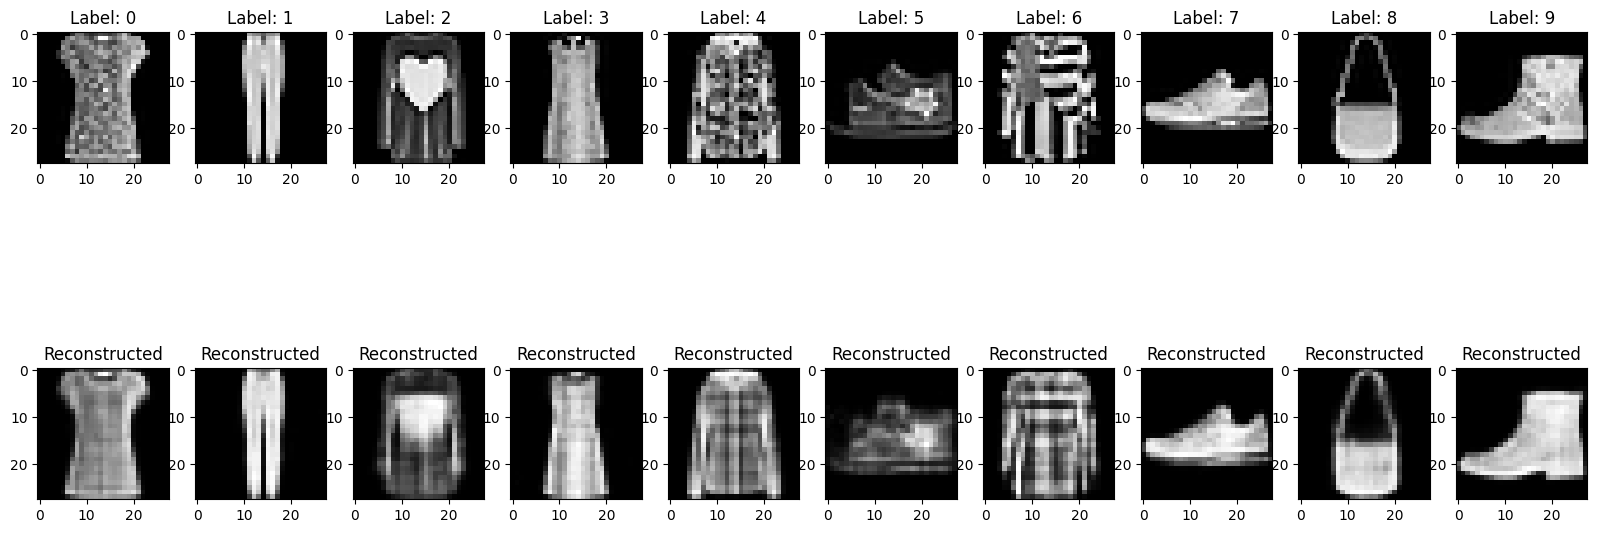

Test Loss: 0.005552199152298272


In [ ]:
images_collection(model, test_dl)
test_loss(test_dl, model, loss_fn)

### Autoencoder with latent space dimension of 256.

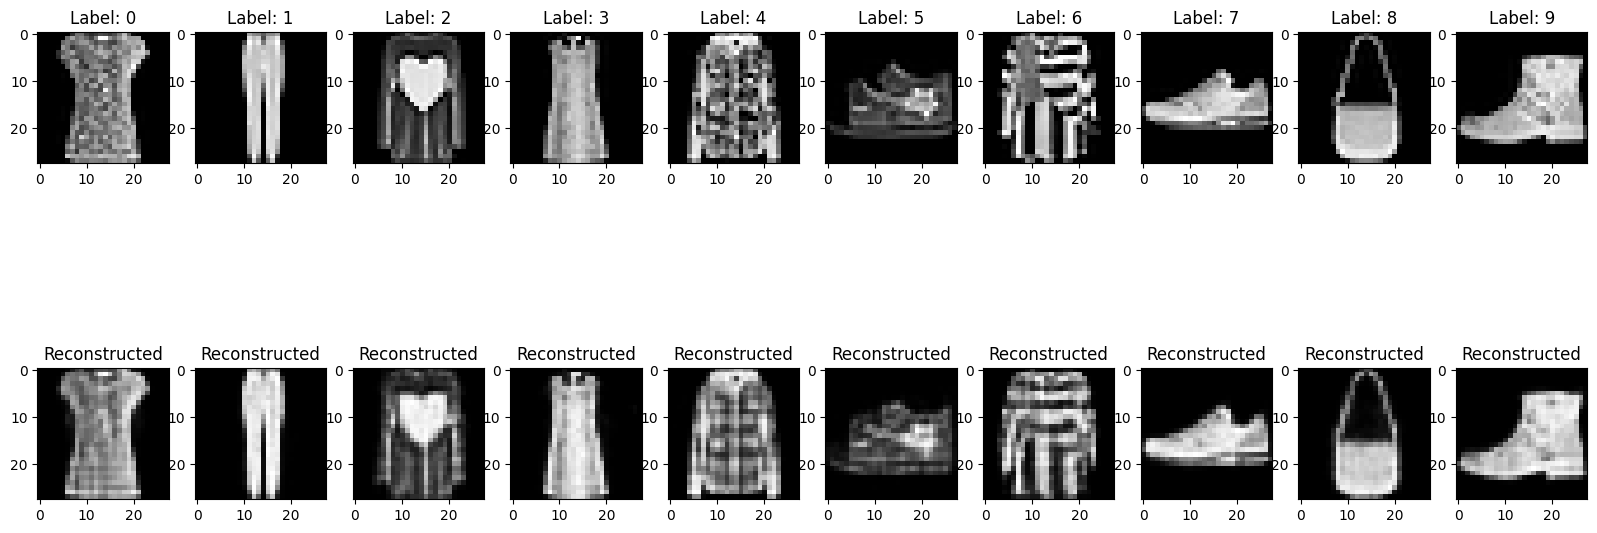

Test Loss: 0.003036904928740114


In [ ]:
images_collection(model2, test_dl)
test_loss(test_dl, model2, loss_fn)

### Autoencoder with latent space dimension of 32 and a deeper architecture.

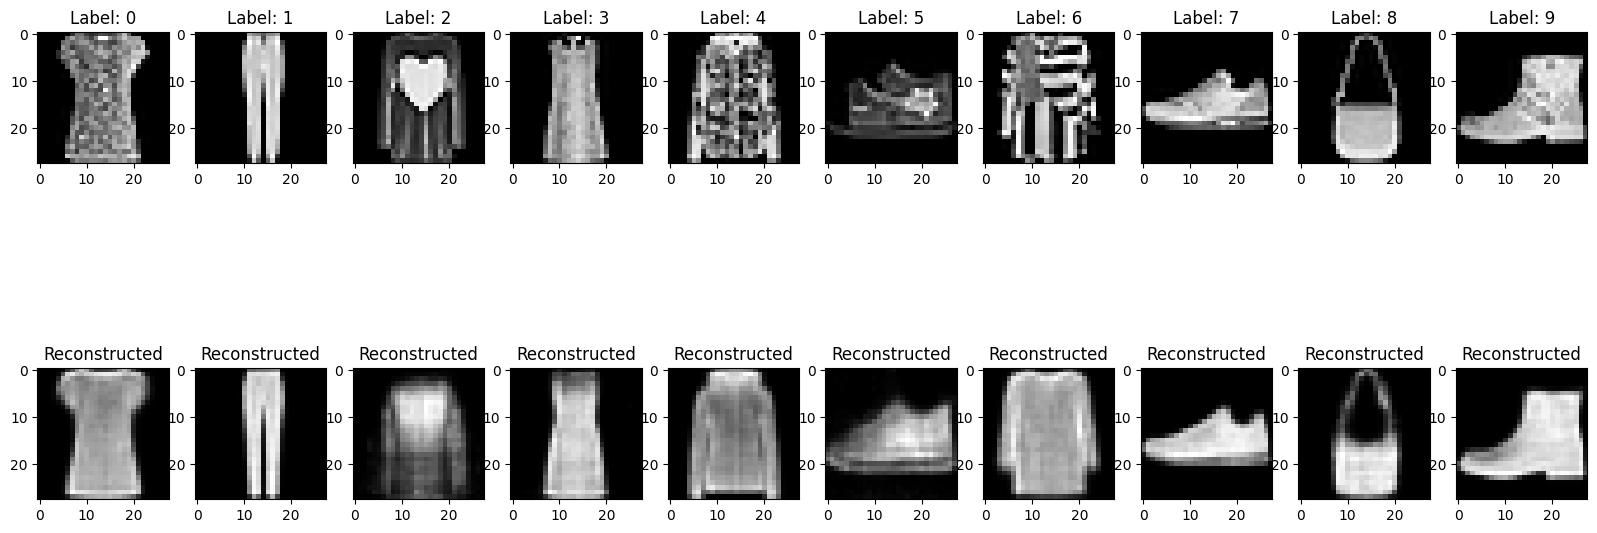

Test Loss: 0.01101377621293068


In [ ]:
images_collection(model3, test_dl)
test_loss(test_dl, model3, loss_fn)

### Autoencoder with latent space dimension of 32 and a shallow architecture.  

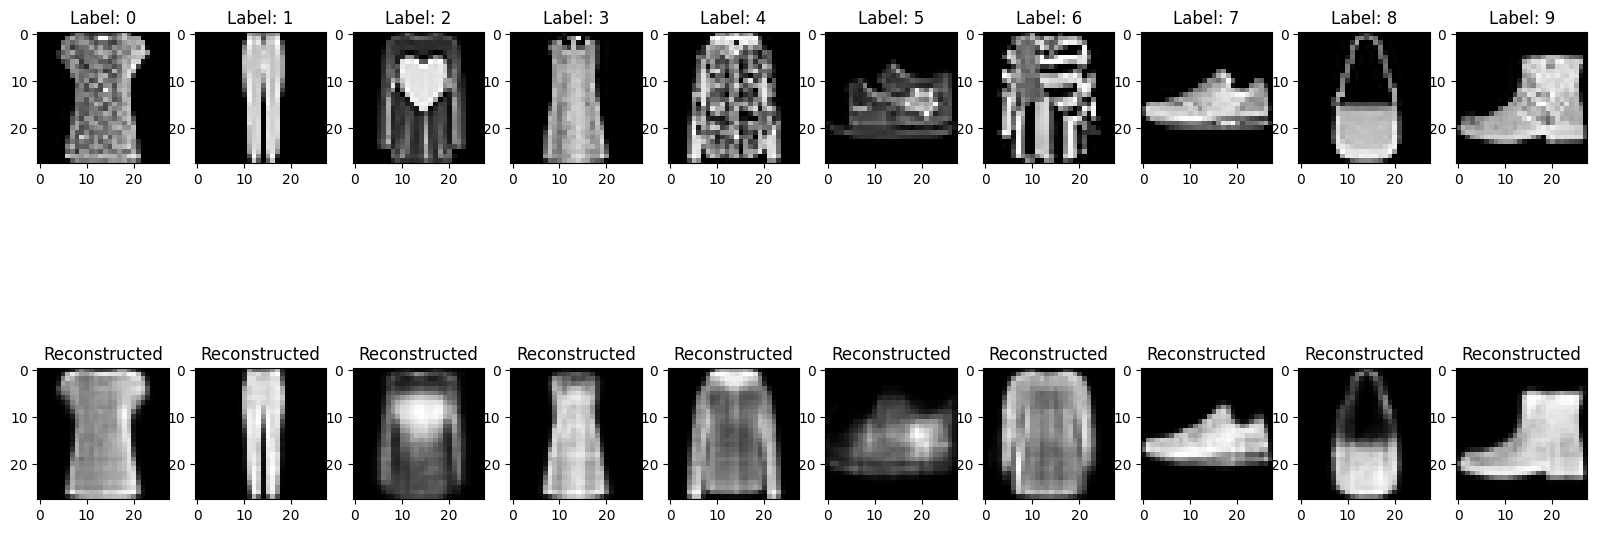

Test Loss: 0.008856129935011267


In [ ]:
images_collection(model4, test_dl)
test_loss(test_dl, model4, loss_fn)

# **REPORT**
---
## Autoencoder :

An autoencoder is a neural network that learns to compress input data into a lower-dimensional representation and then reconstruct the original input from that representation.

---

## Latent Space :


A latent space is a compressed feature representation learned by the model that captures important information from the input data.

---

## Experimentation on Latent Size and Reconstruction Quality


The objective  was to analyze how variations in latent space dimensions and network architecture influence reconstruction loss in autoencoders.

Multiple autoencoders were designed with different latent space dimensions and architectural depths. The following configurations were evaluated:

- Latent Dimension = 128                       : MSELoss on test_data = 0.0055
- Latent Dimension = 256                       : MSELoss on test_data = 0.0030
- Latent Dimension = 32 (Deeper Architecture)  : MSELoss on test_data = 0.0110
- Latent Dimension = 32 (Shallow Architecture) : MSELoss on test_data = 0.0088

Observation:

Larger latent dimensions produced better reconstruction quality because more information could be preserved. We observe the model with latent space dimension 256 produces reconstructed images nearly identical to the input images. But model with 128 doesn't match it's performance

Smaller latent dimensions introduced information bottlenecks, causing loss of information and degrading reconstructed image.
This shows that reducing latent space dimensions force compression and loss of some features.
We observe that reconstruction is blurred or losing some important characteristics ie. design of the top.

---

## Experimentation on Architecture of Autoencoders  

The objective was to analyze the effect of architecture of autoencoders on the recontruction image.

Autoencoders designed for this experimentation are :
- Latent Dimension = 32 (Deeper Architecture)  : MSELoss on test_data = 0.0110
- Latent Dimension = 32 (Shallow Architecture) : MSELoss on test_data = 0.0088

Observation :
- Model with shallow architecture performed better than deeper architecture. We could clearly say the shallow model's reconstruction was than the deeper model.

- We observe the training speed and convergence of shallow model was faster than the deeper model

- This could possibly slower updates in the gradients of the deeper model. It required a longer epochs or a higher learning rates
---
## Conclusion
The experiments depict the trade-off between the reconstruction performance and latent size. We could say generally larger latent spaces could reconstruct better. Also, the experiments indicated the deeper architectures are not always better. Deeper models requires a higher epochs to converge as they deal with larger parameters.

---